<a href="https://colab.research.google.com/github/Maruf-16203091/3d-next-app/blob/main/drive_weatherly5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ======================================
# IMPORTS
# ======================================
import os
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from PIL import Image
from google.colab import drive, files
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ======================================
# SETTINGS
# ======================================
data_dir = '/content/drive/MyDrive/weather_data'
batch_size = 32
seed = 42
num_epochs = 70
patience = 15  # can adjust
mixup_alpha = 0.3  # optional, lower alpha
use_mixup = mixup_alpha > 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "best_weather_resnet18.pth"

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

drive.mount('/content/drive', force_remount=False)

# ======================================
# TRANSFORMS
# ======================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======================================
# DATASET
# ======================================
base_dataset = datasets.ImageFolder(root=data_dir)
class_counts = Counter([s[1] for s in base_dataset.samples])
print("Raw counts per class:", class_counts)
class_names = base_dataset.classes
print("Classes:", class_names)

# train/test split
total_len = len(base_dataset)
train_len = int(0.8 * total_len)
val_len = total_len - train_len
train_ds, test_ds = torch.utils.data.random_split(base_dataset, [train_len, val_len],
                                                  generator=torch.Generator().manual_seed(seed))
train_ds.dataset.transform = train_transform
test_ds.dataset.transform = test_transform

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_ds)}, Validation samples: {len(test_ds)}")

# ======================================
# MODEL: ResNet18
# ======================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),  # Reduced dropout
    nn.Linear(in_features, len(class_names))
)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

# ======================================
# LOSS, OPTIMIZER, SCHEDULER
# ======================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)  # increased LR
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# ======================================
# MIXUP
# ======================================
def mixup_data(x, y, alpha=1.0):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)






Mounted at /content/drive
Raw counts per class: Counter({1: 504, 0: 500, 2: 500, 3: 500, 4: 500})
Classes: ['clear', 'foggy', 'partly cloudy', 'rainy', 'snowy']
Train samples: 2003, Validation samples: 501
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


In [2]:
# ======================================
# TRAINING LOOP
# ======================================
best_val_acc = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0

    for images, labels in tqdm(train_dl, desc=f"Epoch {epoch}/{num_epochs} - Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        total_train += images.size(0)

    epoch_train_loss = train_loss / total_train
    epoch_train_acc = 100.0 * (train_correct / total_train)

    # Validation
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_dl, desc=f"Epoch {epoch}/{num_epochs} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * images.size(0)
            val_correct += (preds == labels).sum().item()
            total_val += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = 100.0 * (val_correct / total_val)

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    scheduler.step()

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': best_val_acc,
            'class_names': class_names
        }, save_path)
        print(f"✅ Saved new best model (Val Acc: {best_val_acc:.2f}%) -> {save_path}")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping triggered. No improvement for {patience} epochs.")
        break

Epoch 1/70 - Validation: 100%|██████████| 16/16 [01:44<00:00,  6.53s/it]


Epoch 01 | Train Loss: 1.2532 | Val Loss: 1.1741 | Train Acc: 42.04% | Val Acc: 63.27%
✅ Saved new best model (Val Acc: 63.27%) -> best_weather_resnet18.pth


Epoch 2/70 - Validation: 100%|██████████| 16/16 [00:07<00:00,  2.27it/s]


Epoch 02 | Train Loss: 1.0330 | Val Loss: 1.0078 | Train Acc: 54.62% | Val Acc: 70.46%
✅ Saved new best model (Val Acc: 70.46%) -> best_weather_resnet18.pth


Epoch 3/70 - Validation: 100%|██████████| 16/16 [00:07<00:00,  2.21it/s]


...

Epoch 36 | Train Loss: 0.6290 | Val Loss: 0.8963 | Train Acc: 56.27% | Val Acc: 74.65%
No improvement for 13 epoch(s).


Epoch 37/70 - Validation: 100%|██████████| 16/16 [00:07<00:00,  2.12it/s]


Epoch 37 | Train Loss: 0.6475 | Val Loss: 0.9075 | Train Acc: 68.40% | Val Acc: 74.25%
No improvement for 14 epoch(s).


Epoch 38/70 - Validation: 100%|██████████| 16/16 [00:06<00:00,  2.30it/s]

Epoch 38 | Train Loss: 0.6130 | Val Loss: 0.9178 | Train Acc: 58.26% | Val Acc: 73.65%
No improvement for 15 epoch(s).
⏹️ Early stopping triggered. No improvement for 15 epochs.


Loaded best model from checkpoint with val_acc: 76.84630738522954
Final classification report (best model):
               precision    recall  f1-score   support

        clear     0.6311    0.8105    0.7097        95
        foggy     0.9109    0.8679    0.8889       106
partly cloudy     0.7193    0.8817    0.7923        93
        rainy     0.7976    0.6979    0.7444        96
        snowy     0.8375    0.6036    0.7016       111

     accuracy                         0.7685       501
    macro avg     0.7793    0.7723    0.7674       501
 weighted avg     0.7843    0.7685    0.7678       501



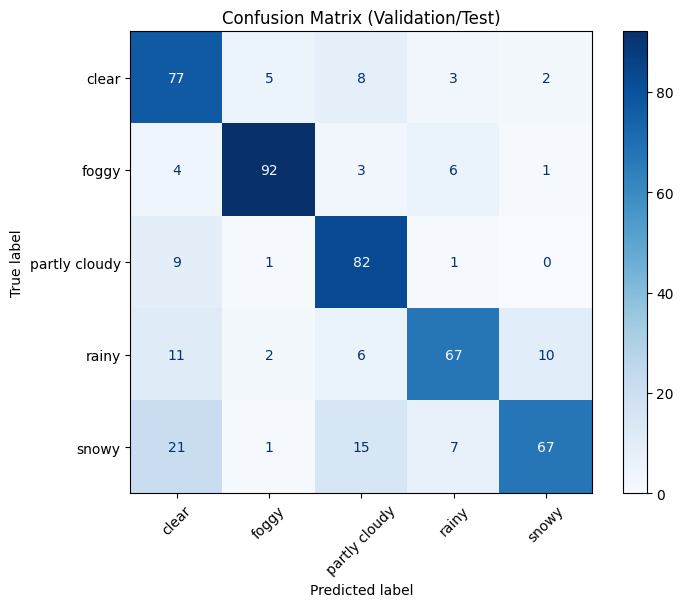

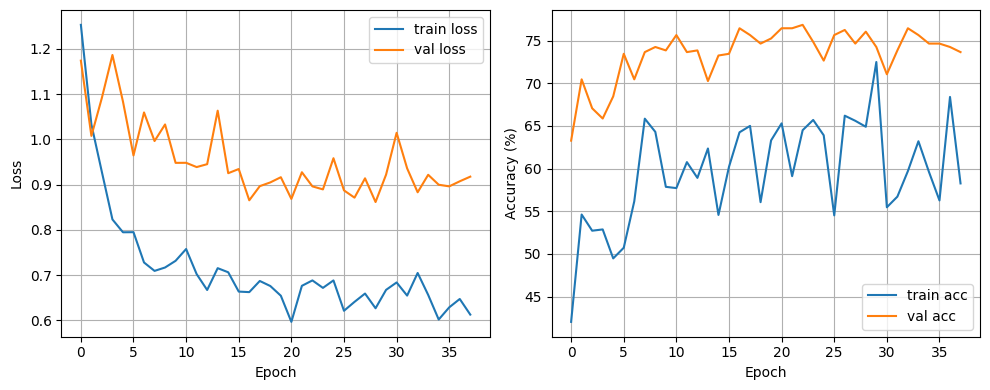

In [3]:
# ======================================
# FINAL EVALUATION
# ======================================
checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print("Loaded best model from checkpoint with val_acc:", checkpoint.get('val_acc'))

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Final classification report (best model):")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Validation/Test)")
plt.xticks(rotation=45)
plt.show()

# ======================================
# PLOT CURVES
# ======================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label='train loss')
plt.plot(history["val_loss"], label='val loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label='train acc')
plt.plot(history["val_acc"], label='val acc')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load Flan-T5 model
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
text_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to(device)

# -----------------------------
# Function to generate instruction
# -----------------------------
def generate_instruction(predicted_class, recommended_speed):
    """
    Generates a driving instruction and reasoning for a given weather class and recommended speed.
    """
    prompt = (
        f"Weather: {predicted_class}. "
        f"Recommend a driving speed of {recommended_speed} and explain briefly why it is safe and appropriate. "
        "Do not repeat the prompt; just write the instruction."
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = text_model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=3,
        no_repeat_ngram_size=2
    )
    instruction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return instruction

# -----------------------------
# Function: Upload & test weather images
# -----------------------------
def test_uploaded_image_with_speed(model, class_names, transform, device):
    """
    Upload images from PC, predict weather using the model, and generate driving instruction with reasoning.
    """
    SPEED_GUIDELINES = {
        "clear": "80 km/h",
        "partly cloudy": "70 km/h",
        "rainy": "50 km/h",
        "snowy": "40 km/h",
        "foggy": "30 km/h",
    }

    uploaded = files.upload()

    for filename in uploaded.keys():
        # Load and display image
        img = Image.open(filename).convert('RGB')
        plt.imshow(img)
        plt.axis('off')
        plt.title(filename)
        plt.show()

        # Transform and predict
        img_t = transform(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            output = model(img_t)
            probs = torch.softmax(output, dim=1)
            conf, pred = torch.max(probs, 1)

        predicted_class = class_names[pred.item()]
        confidence = conf.item()
        recommended_speed = SPEED_GUIDELINES.get(predicted_class, "unspecified")

        # Print prediction
        print(f"Predicted weather: {predicted_class} ({confidence*100:.1f}% confidence)")
        print(f"Recommended speed: {recommended_speed}")

        # Generate instruction using Flan-T5
        instruction = generate_instruction(predicted_class, recommended_speed)
        print("\nDriving Instruction & Reasoning:\n", instruction)




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Saving Fog1 (547).png to Fog1 (547).png


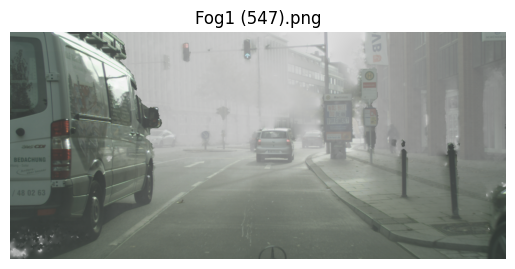

Predicted weather: foggy (86.7% confidence)
Recommended speed: 30 km/h

Driving Instruction & Reasoning:
 Weather: foggy. Recommend a driving speed of 30 km/h and explain briefly why it is safe and appropriate. Do not repeat the prompt; just write the instruction.


In [5]:
test_uploaded_image_with_speed(model, class_names, test_transform, device)